# Experiment 3: PLA vs MLP (A/B Experiment)

In [23]:

# -- coding: utf-8 --
import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
IMG_SIZE = 32
TEST_SIZE = 0.2
VAL_SIZE = 0.1
BATCH_SIZE = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


In [24]:
import os, glob
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from PIL import Image

DATA_DIR  = r"C:/Users/madhu/OneDrive/Desktop/ML-5/Img"
IMG_SIZE  = 32
TEST_SIZE = 0.2
VAL_SIZE  = 0.2
SEED      = 42

def load_dataset_from_filenames(data_dir, img_size=32):
    X, y = [], []
    filenames = glob.glob(os.path.join(data_dir, "*.png"))
    
    for fp in filenames:
        try:
            fname = os.path.basename(fp)
            # take the part before the "-" as class (e.g. "img001")
            cls = fname.split("-")[0]  
            
            img = Image.open(fp).convert("L").resize((img_size, img_size))
            arr = np.asarray(img, dtype=np.float32) / 255.0
            X.append(arr.flatten())
            y.append(cls)
        except Exception as e:
            print("Skipping:", fp, "Error:", e)
            continue

    le = LabelEncoder().fit(y)
    X = np.stack(X)
    y = le.transform(y)
    return X, y, le.classes_

# === Load dataset ===
X, y, CLASSES = load_dataset_from_filenames(DATA_DIR, IMG_SIZE)
num_classes = len(CLASSES)
input_dim   = X.shape[1]

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=SEED, stratify=y_trainval
)

print("Dataset loaded:", X.shape, "classes:", num_classes)
print("Classes:", CLASSES[:10], "...")


ValueError: need at least one array to stack

In [ ]:

class PLAOvR:
    def __init__(self, n_classes, n_features, lr=0.01, epochs=10):
        self.C = n_classes
        self.lr = lr
        self.epochs = epochs
        self.W = np.zeros((n_classes, n_features), dtype=np.float32)
        self.b = np.zeros((n_classes,), dtype=np.float32)
        self.train_losses_ = []

    @staticmethod
    def step(z):
        return (z >= 0).astype(np.float32)

    def fit(self, X, y):
        Y = np.zeros((X.shape[0], self.C), dtype=np.float32)
        Y[np.arange(X.shape[0]), y] = 1.0
        N = X.shape[0]

        for ep in range(self.epochs):
            idx = np.random.permutation(N)
            wrong = 0
            for i in idx:
                x = X[i]
                t = Y[i]
                scores = self.W @ x + self.b
                yhat01 = self.step(scores)
                delta = (t - yhat01)
                if np.any(delta != 0):
                    self.W += self.lr * np.outer(delta, x)
                    self.b += self.lr * delta
                if np.argmax(scores) != np.argmax(t):
                    wrong += 1
            self.train_losses_.append(wrong / N)

    def decision_function(self, X):
        return X @ self.W.T + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.argmax(scores, axis=1)


In [ ]:
pla = PLAOvR(num_classes, input_dim, lr=0.01, epochs=15)
pla.fit(X_train, y_train)

y_pred_train_pla = pla.predict(X_train)
y_pred_val_pla   = pla.predict(X_val)
y_pred_test_pla  = pla.predict(X_test)

print("=== PLA Results ===")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train_pla))
print("Val Accuracy:  ", accuracy_score(y_val, y_pred_val_pla))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_test_pla))
print("\nClassification Report (PLA - Test)")
print(classification_report(y_test, y_pred_test_pla, target_names=CLASSES))


=== PLA Results ===
Train Accuracy: 0.19615032080659944
Val Accuracy:   0.1336996336996337
Test Accuracy:  0.10850439882697947

Classification Report (PLA - Test)
              precision    recall  f1-score   support

      img001       0.00      0.00      0.00        11
      img002       0.00      0.00      0.00        11
      img003       0.00      0.00      0.00        11
      img004       1.00      0.18      0.31        11
      img005       0.00      0.00      0.00        11
      img006       0.00      0.00      0.00        11
      img007       0.00      0.00      0.00        11
      img008       0.00      0.00      0.00        11
      img009       0.00      0.00      0.00        11
      img010       0.00      0.00      0.00        11
      img011       0.00      0.00      0.00        11
      img012       0.00      0.00      0.00        11
      img013       1.00      0.27      0.43        11
      img014       0.00      0.00      0.00        11
      img015       0.03   

c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(256,), activation="relu", p_drop=0.0):
        super().__init__()
        acts = {"relu": nn.ReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid}
        A = acts[activation]
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), A()]
            if p_drop > 0: layers += [nn.Dropout(p_drop)]
            prev = h
        layers += [nn.Linear(prev, num_classes) ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [ ]:

def train_mlp(Xtr, ytr, Xva, yva, hidden, act, opt, lr, batch, epochs=20, wd=0.0, p_drop=0.0):
    Xtr_t = torch.from_numpy(Xtr).float()
    ytr_t = torch.from_numpy(ytr).long()
    Xva_t = torch.from_numpy(Xva).float()
    yva_t = torch.from_numpy(yva).long()

    ds_tr = TensorDataset(Xtr_t, ytr_t)
    dl_tr = DataLoader(ds_tr, batch_size=batch, shuffle=True)

    model = MLP(input_dim, hidden, activation=act, p_drop=p_drop).to(DEVICE)
    if opt.lower()=="sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    tr_losses, va_losses = [], []
    for ep in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        tr_loss = running / len(ds_tr)

        model.eval()
        with torch.no_grad():
            logits_va = model(Xva_t.to(DEVICE))
            va_loss = criterion(logits_va, yva_t.to(DEVICE)).item()
        tr_losses.append(tr_loss); va_losses.append(va_loss)

    model.eval()
    with torch.no_grad():
        val_logits = model(Xva_t.to(DEVICE)).cpu().numpy()
        val_pred = val_logits.argmax(1)
        val_acc  = accuracy_score(yva, val_pred)
    return model, np.array(tr_losses), np.array(va_losses), val_acc


In [ ]:

grid = [
    dict(hidden=(128,),   act="relu", opt="adam", lr=1e-3, batch=64, epochs=20),
    dict(hidden=(256,128),act="relu", opt="adam", lr=1e-3, batch=64, epochs=20),
    dict(hidden=(256,),   act="tanh", opt="sgd",  lr=1e-2, batch=64, epochs=20),
]

best = None
history = {}
for i, hp in enumerate(grid, 1):
    model, trL, vaL, va_acc = train_mlp(X_train, y_train, X_val, y_val, **hp)
    history[f"cfg{i}"] = dict(hp=hp, trL=trL, vaL=vaL, va_acc=va_acc, model=model)
    if best is None or va_acc > best["va_acc"]:
        best = dict(idx=i, **history[f"cfg{i}"])

best_model = best["model"]
print("=== Best MLP Config ===")
print(best["hp"])
print("Val Accuracy:", best["va_acc"])


=== Best MLP Config ===
{'hidden': (256,), 'act': 'tanh', 'opt': 'sgd', 'lr': 0.01, 'batch': 64, 'epochs': 20}
Val Accuracy: 0.2490842490842491


In [ ]:

X_test_t = torch.from_numpy(X_test).float().to(DEVICE)
with torch.no_grad():
    test_logits = best_model(X_test_t).cpu().numpy()
y_pred_test_mlp = test_logits.argmax(1)

print("=== MLP Results ===")
print("Test Accuracy:", accuracy_score(y_test, y_pred_test_mlp))
print("\nClassification Report (MLP - Test)")
print(classification_report(y_test, y_pred_test_mlp, target_names=CLASSES))


=== MLP Results ===
Test Accuracy: 0.26099706744868034

Classification Report (MLP - Test)
              precision    recall  f1-score   support

      img001       0.36      0.36      0.36        11
      img002       0.00      0.00      0.00        11
      img003       0.00      0.00      0.00        11
      img004       0.00      0.00      0.00        11
      img005       0.00      0.00      0.00        11
      img006       0.00      0.00      0.00        11
      img007       0.12      0.27      0.16        11
      img008       0.24      0.45      0.31        11
      img009       1.00      0.36      0.53        11
      img010       0.24      0.73      0.36        11
      img011       1.00      0.36      0.53        11
      img012       0.56      0.45      0.50        11
      img013       0.26      0.91      0.41        11
      img014       0.67      0.18      0.29        11
      img015       0.12      0.45      0.19        11
      img016       0.00      0.00      0.00 

c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\madhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

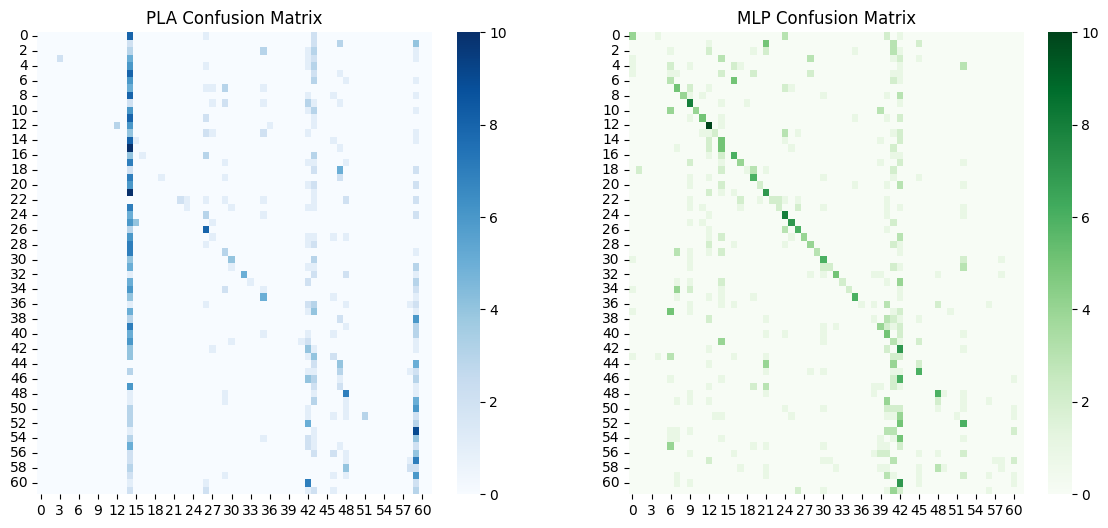

In [ ]:

import seaborn as sns

cm_pla = confusion_matrix(y_test, y_pred_test_pla)
cm_mlp = confusion_matrix(y_test, y_pred_test_mlp)

fig, ax = plt.subplots(1, 2, figsize=(14,6))
sns.heatmap(cm_pla, annot=False, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("PLA Confusion Matrix")
sns.heatmap(cm_mlp, annot=False, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("MLP Confusion Matrix")
plt.show()


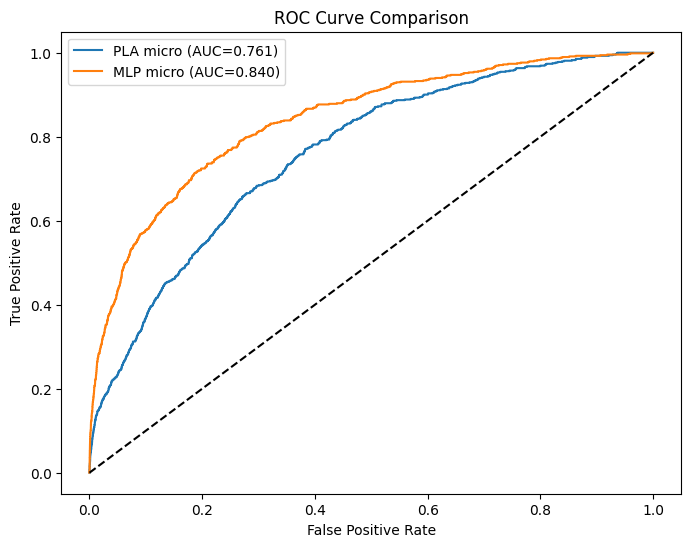

In [ ]:

y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
scores_pla = pla.decision_function(X_test)
scores_mlp = test_logits

fpr_micro_pla, tpr_micro_pla, _ = roc_curve(y_test_bin.ravel(), scores_pla.ravel())
fpr_micro_mlp, tpr_micro_mlp, _ = roc_curve(y_test_bin.ravel(), scores_mlp.ravel())
roc_auc_micro_pla = auc(fpr_micro_pla, tpr_micro_pla)
roc_auc_micro_mlp = auc(fpr_micro_mlp, tpr_micro_mlp)

plt.figure(figsize=(8,6))
plt.plot(fpr_micro_pla, tpr_micro_pla, label=f"PLA micro (AUC={roc_auc_micro_pla:.3f})")
plt.plot(fpr_micro_mlp, tpr_micro_mlp, label=f"MLP micro (AUC={roc_auc_micro_mlp:.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


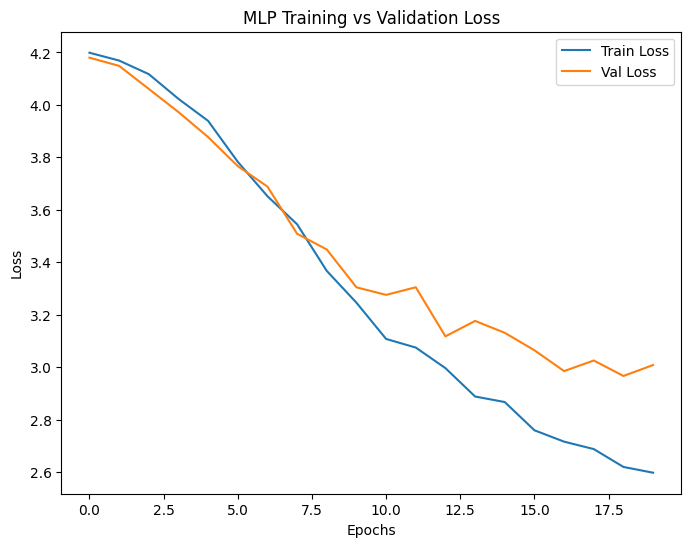

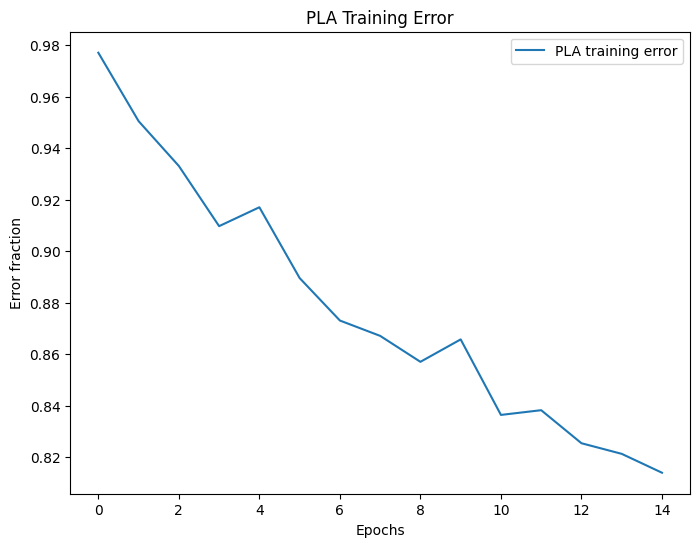

In [ ]:

plt.figure(figsize=(8,6))
plt.plot(best["trL"], label="Train Loss")
plt.plot(best["vaL"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(pla.train_losses_, label="PLA training error")
plt.xlabel("Epochs")
plt.ylabel("Error fraction")
plt.title("PLA Training Error")
plt.legend()
plt.show()
